## Week 6 Assignment 
Name : Sakshi Kiran Kekan 
College : Sanjivani College of Engineering, Kopargaon 
Domain : Data Science 

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.datasets import mnist

In [2]:
# Load MNIST dataset
(x_train, y_train), (x_test, y_test) = mnist.load_data()

print("Training images shape :", x_train.shape)
print("Training labels shape :", y_train.shape)
print("Testing images shape  :", x_test.shape)
print("Testing labels shape  :", y_test.shape)

Training images shape : (60000, 28, 28)
Training labels shape : (60000,)
Testing images shape  : (10000, 28, 28)
Testing labels shape  : (10000,)


In [3]:
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

print("Pixel value range:", x_train.min(), "to", x_train.max())

Pixel value range: 0.0 to 1.0


In [4]:
x_train = np.reshape(x_train, (len(x_train), 28, 28, 1))
x_test = np.reshape(x_test, (len(x_test), 28, 28, 1))

print("Training Shape:", x_train.shape)
print("Testing Shape :", x_test.shape)

Training Shape: (60000, 28, 28, 1)
Testing Shape : (10000, 28, 28, 1)


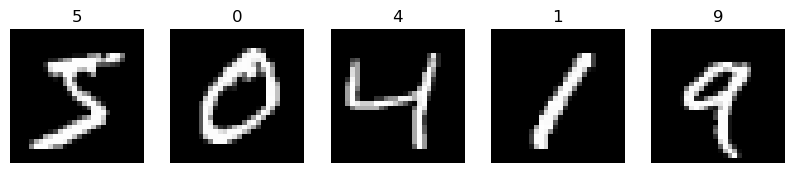

In [5]:
plt.figure(figsize=(10,2))

for i in range(5):
    plt.subplot(1,5,i+1)
    plt.imshow(x_train[i].reshape(28,28), cmap='gray')
    plt.title(y_train[i])
    plt.axis('off')

plt.show()

In [6]:
# Noise level (change this value to increase or decrease noise)
noise_factor = 0.5

In [7]:
# Add random Gaussian noise
x_train_noisy = x_train + noise_factor * np.random.normal(
    loc=0.0,
    scale=1.0,
    size=x_train.shape
)

x_test_noisy = x_test + noise_factor * np.random.normal(
    loc=0.0,
    scale=1.0,
    size=x_test.shape
)

In [8]:
x_train_noisy = np.clip(x_train_noisy, 0., 1.)
x_test_noisy = np.clip(x_test_noisy, 0., 1.)

In [9]:
print("Original Training Shape :", x_train.shape)
print("Noisy Training Shape    :", x_train_noisy.shape)

print("Original Testing Shape  :", x_test.shape)
print("Noisy Testing Shape     :", x_test_noisy.shape)

Original Training Shape : (60000, 28, 28, 1)
Noisy Training Shape    : (60000, 28, 28, 1)
Original Testing Shape  : (10000, 28, 28, 1)
Noisy Testing Shape     : (10000, 28, 28, 1)


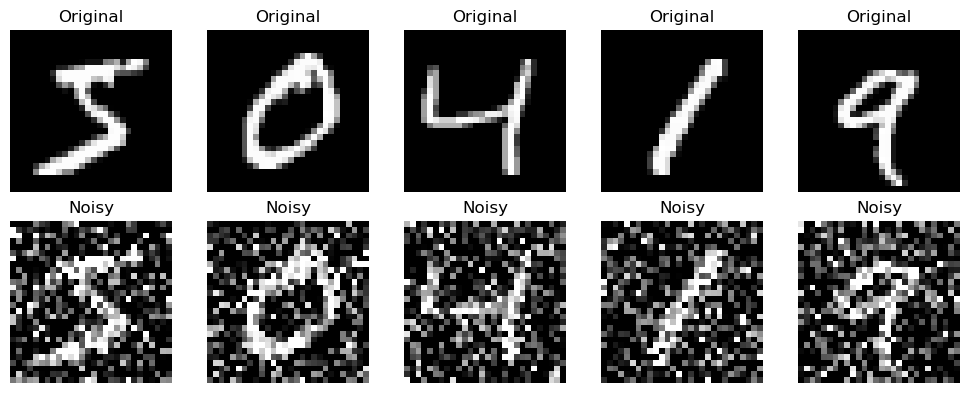

In [10]:
plt.figure(figsize=(10,4))

for i in range(5):

    # Original Image
    plt.subplot(2,5,i+1)
    plt.imshow(x_train[i].reshape(28,28), cmap='gray')
    plt.title("Original")
    plt.axis('off')

    # Noisy Image
    plt.subplot(2,5,i+6)
    plt.imshow(x_train_noisy[i].reshape(28,28), cmap='gray')
    plt.title("Noisy")
    plt.axis('off')

plt.tight_layout()
plt.show()

In [11]:
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, UpSampling2D
from tensorflow.keras.models import Model

In [12]:
input_img = Input(shape=(28, 28, 1))

In [13]:
# Encoder
x = Conv2D(32, (3,3), activation='relu', padding='same')(input_img)
x = MaxPooling2D((2,2), padding='same')(x)

x = Conv2D(16, (3,3), activation='relu', padding='same')(x)
encoded = MaxPooling2D((2,2), padding='same')(x)

In [14]:
# Decoder
x = Conv2D(16, (3,3), activation='relu', padding='same')(encoded)
x = UpSampling2D((2,2))(x)

x = Conv2D(32, (3,3), activation='relu', padding='same')(x)
x = UpSampling2D((2,2))(x)

decoded = Conv2D(1, (3,3), activation='sigmoid', padding='same')(x)

In [15]:
autoencoder = Model(input_img, decoded)

In [16]:
autoencoder.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)             │ (None, 28, 28, 1)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d (Conv2D)                      │ (None, 28, 28, 32)          │             320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 14, 14, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 14, 14, 16)          │           4,624 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 7, 7, 16)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 7, 7, 16)            │           2,320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ up_sampling2d (UpSampling2D)         │ (None, 14, 14, 16)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_3 (Conv2D)                    │ (None, 14, 14, 32)          │           4,640 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ up_sampling2d_1 (UpSampling2D)       │ (None, 28, 28, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_4 (Conv2D)                    │ (None, 28, 28, 1)           │             289 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 12,193 (47.63 KB)

 Trainable params: 12,193 (47.63 KB)

 Non-trainable params: 0 (0.00 B)

In [17]:
print(autoencoder)

<Functional name=functional, built=True>


In [18]:
autoencoder.compile(
    optimizer='adam',
    loss='binary_crossentropy'
)

In [19]:
history = autoencoder.fit(
    x_train_noisy,      # Input (Noisy Images)
    x_train,            # Target (Clean Images)
    epochs=10,
    batch_size=128,
    shuffle=True,
    validation_data=(x_test_noisy, x_test)
)

Epoch 1/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 107s 216ms/step - loss: 0.1859 - val_loss: 0.1256
Epoch 2/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 101s 216ms/step - loss: 0.1205 - val_loss: 0.1153
Epoch 3/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 101s 214ms/step - loss: 0.1137 - val_loss: 0.1106
Epoch 4/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 99s 212ms/step - loss: 0.1105 - val_loss: 0.1085
Epoch 5/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 99s 211ms/step - loss: 0.1083 - val_loss: 0.1064
Epoch 6/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 98s 209ms/step - loss: 0.1066 - val_loss: 0.1048
Epoch 7/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 143s 210ms/step - loss: 0.1051 - val_loss: 0.1034
Epoch 8/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 99s 211ms/step - loss: 0.1038 - val_loss: 0.1023
Epoch 9/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 105s 223ms/step - loss: 0.1019 - val_loss: 0.1008


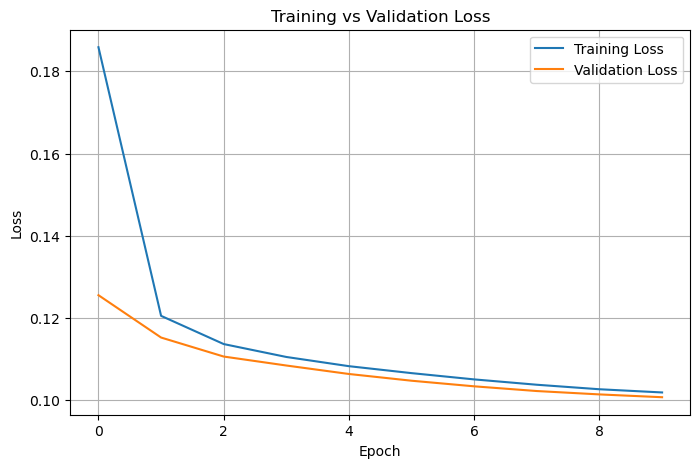

In [20]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

plt.show()

In [21]:
# Generate denoised images
denoised_images = autoencoder.predict(x_test_noisy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 10s 29ms/step


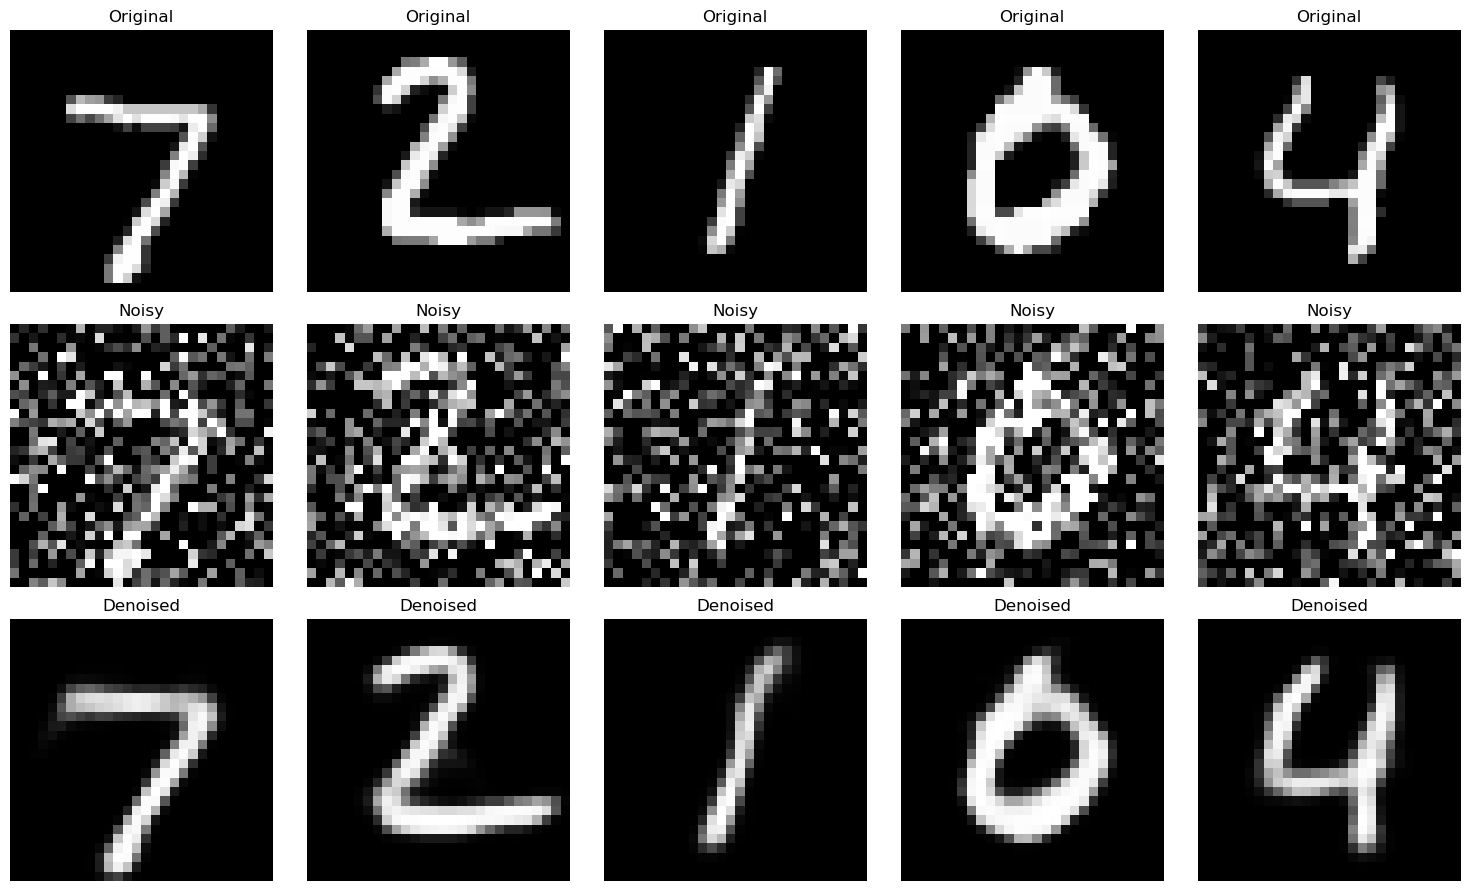

In [22]:
import matplotlib.pyplot as plt

n = 5  # Number of images to display

plt.figure(figsize=(15, 9))

for i in range(n):

    # Original Image
    plt.subplot(3, n, i + 1)
    plt.imshow(x_test[i].reshape(28, 28), cmap='gray')
    plt.title("Original")
    plt.axis('off')

    # Noisy Image
    plt.subplot(3, n, i + 1 + n)
    plt.imshow(x_test_noisy[i].reshape(28, 28), cmap='gray')
    plt.title("Noisy")
    plt.axis('off')

    # Denoised Image
    plt.subplot(3, n, i + 1 + 2 * n)
    plt.imshow(denoised_images[i].reshape(28, 28), cmap='gray')
    plt.title("Denoised")
    plt.axis('off')

plt.tight_layout()
plt.show()

# Results and Observations

## Objective
The objective of this assignment was to build a **Denoising Autoencoder** capable of reconstructing clean MNIST handwritten digit images from noisy input images. The model was trained to learn meaningful features from noisy data and generate denoised outputs.

---

## Data Preparation
- Loaded the MNIST handwritten digit dataset using `tensorflow.keras.datasets`.
- Normalized the pixel values from **0–255** to **0–1**.
- Reshaped the images to **(28, 28, 1)** for use with a Convolutional Neural Network (CNN).
- Added **Gaussian noise** with a noise factor of **0.5** to generate noisy input images for training and testing.

---

## Model Architecture
A **Convolutional Denoising Autoencoder** was implemented with the following components:

### Encoder
- Conv2D (32 filters, ReLU activation)
- MaxPooling2D
- Conv2D (16 filters, ReLU activation)
- MaxPooling2D

### Decoder
- Conv2D (16 filters, ReLU activation)
- UpSampling2D
- Conv2D (32 filters, ReLU activation)
- UpSampling2D
- Conv2D (1 filter, Sigmoid activation)

The **Sigmoid** activation function in the output layer ensures that reconstructed pixel values remain between **0 and 1**.

---

## Training Configuration

| Parameter | Value |
|-----------|-------|
| Optimizer | Adam |
| Loss Function | Binary Crossentropy |
| Epochs | 10 |
| Batch Size | 128 |

During training, both the training loss and validation loss decreased steadily, indicating that the model successfully learned to reconstruct clean images from noisy inputs.

---

## Results
- Gaussian noise was successfully added to the original MNIST images.
- The trained autoencoder effectively removed most of the noise from the test images.
- The reconstructed (denoised) images closely resembled the original handwritten digits.
- The overall structure and important features of the digits were preserved after reconstruction.
- Some reconstructed images appeared slightly blurred, which is a common characteristic of autoencoder-based image reconstruction.

---

## Challenges
- Increasing the noise factor made the reconstruction task more difficult.
- Training for a small number of epochs may not achieve the best denoising performance.
- Very high noise levels can reduce reconstruction accuracy and lead to loss of fine image details.

---

## Conclusion
The Denoising Autoencoder successfully learned to reconstruct clean handwritten digit images from noisy inputs. The model demonstrated good denoising performance by removing Gaussian noise while preserving the essential structure of the digits. This experiment highlights the effectiveness of convolutional autoencoders for image denoising and image reconstruction tasks.